# Bao Cao Tong Hop — Sentimind: Mental Health Sentiment Analysis

**De tai:** So sanh RNN (BiLSTM) vs Transformer (BERTweet) vs LLM (Gemini) trong bai toan phan loai cam xuc suc khoe tam than tu mang xa hoi.

**Cau hoi nghien cuu:** *"Trong bai toan phan loai cam xuc suc khoe tam than, model nao (RNN / Transformer / LLM) hieu ngu nghia (semantic) tot hon va tai sao?"*

**Cau truc bao cao:**

1. Cai dat va cau hinh moi truong
2. Du lieu va tien xu ly
3. Phan tich tham do du lieu (EDA)
4. Ket qua huan luyen va danh gia tung model
5. Phan tich ngu nghia (STS + Clustering)
6. So sanh tong hop va kiem dinh
7. Phan tich loi
8. Ket luan va huong phat trien

**Chuan bao cao tham chieu:** ACL/EMNLP Evaluation Best Practices, scikit-learn classification report, confusion matrix heatmap.

In [1]:
# ============================================================
# 1. CAI DAT VA CAU HINH MOI TRUONG
# ============================================================
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

# Duong dan tuong doi
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"
ARTIFACTS = PROJECT_ROOT / "data" / "artifacts"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# In phien ban thu vien (chuan bao cao thuc nghiem)
import torch, transformers, sklearn, sentence_transformers, umap
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"sentence-tr  : {sentence_transformers.__version__}")
print(f"UMAP         : {umap.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Device       : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Seed         : {RANDOM_SEED}")

Python       : 3.13.11
PyTorch      : 2.10.0+cu128
Transformers : 5.3.0
scikit-learn : 1.8.0
sentence-tr  : 5.2.3
UMAP         : 0.5.11
NumPy        : 2.4.2
Pandas       : 3.0.0
Device       : cuda
Seed         : 42


## 2. Du Lieu va Tien Xu Ly

### 2.1 Dataset 1 — Kaggle Mental Health Sentiment

- **Nguon**: kaggle.com/datasets/suchintikasarkat/sentiment-analysis-for-mental-health
- **So cot**: `statement` (text), `status` (label)
- **Nhan**: Normal, Depression, Anxiety, Bipolar, Personality Disorder, Stress, Suicidal (7 lop)

### 2.2 Dataset 2 — TweetEval Sentiment (tham khao)

- **Nguon**: huggingface.co/datasets/cardiffnlp/tweet_eval (subset: sentiment)
- **Vai tro**: Pre-training / fine-tuning BERTweet tren tweet data truoc khi transfer sang mental health
- **Ghi chu**: BERTweet (vinai/bertweet-base) da pre-train tren 850M tweet — tuong duong hieu qua transfer

### 2.3 Pipeline tien xu ly

1. Unicode NFKC normalisation
2. Loai bo URL, @mentions
3. Giu text hashtag (bo ky tu `#`)
4. Loai bo HTML entities, ky tu dieu khien
5. Ghep khoang trang, lowercase
6. Bo van ban < 3 ky tu sau khi clean
7. Loai bo ban ghi trung lap (text + label_id)
8. Stratified split 70/15/15 (seed=42)

In [9]:
# ============================================================
# 2. DOC DU LIEU VA BAO CAO TIEN XU LY
# ============================================================

# Doc bao cao tien xu ly
prep = json.loads((ARTIFACTS / "preprocessing_report.json").read_text())

print("=== BAO CAO TIEN XU LY ===")
print(f"So dong goc            : {prep['initial_count']:,}")
print(f"Loai bo — null         : {prep['dropped']['null_rows']:,}")
print(f"Loai bo — text ngan    : {prep['dropped']['short_text']:,}")
print(f"Loai bo — label la     : {prep['dropped']['unknown_labels']:,}")
print(f"Loai bo — trung lap    : {prep['dropped']['duplicates']:,}")
print(f"Tong loai bo           : {prep['total_dropped']:,} ({prep['total_dropped']/prep['initial_count']*100:.1f}%)")
print(f"So dong sau xu ly      : {prep['final_count']:,}")
print()

# Phan phoi lop
print("=== PHAN PHOI LOP ===")
dist = prep["class_distribution"]
for k, v in sorted(dist.items(), key=lambda x: int(x[0])):
    pct = v["count"] / prep["final_count"] * 100
    print(f"  [{k}] {v['label']:<25s} {v['count']:>6,}  ({pct:5.1f}%)")

print()
splits = prep["splits"]
print("=== CHIA TAP DU LIEU ===")
for split_name, count in splits.items():
    print(f"  {split_name:<6s}: {count:>6,} mau ({count/prep['final_count']*100:.0f}%)")

=== BAO CAO TIEN XU LY ===
So dong goc            : 53,043
Loai bo — null         : 362
Loai bo — text ngan    : 6
Loai bo — label la     : 0
Loai bo — trung lap    : 1,630
Tong loai bo           : 1,998 (3.8%)
So dong sau xu ly      : 51,045

=== PHAN PHOI LOP ===
  [0] Normal                    16,007  ( 31.4%)
  [1] Depression                15,093  ( 29.6%)
  [2] Anxiety                    3,620  (  7.1%)
  [3] Bipolar                    2,501  (  4.9%)
  [4] Personality disorder         894  (  1.8%)
  [5] Stress                     2,292  (  4.5%)
  [6] Suicidal                  10,638  ( 20.8%)

=== CHIA TAP DU LIEU ===
  train : 35,731 mau (70%)
  val   :  7,657 mau (15%)
  test  :  7,657 mau (15%)


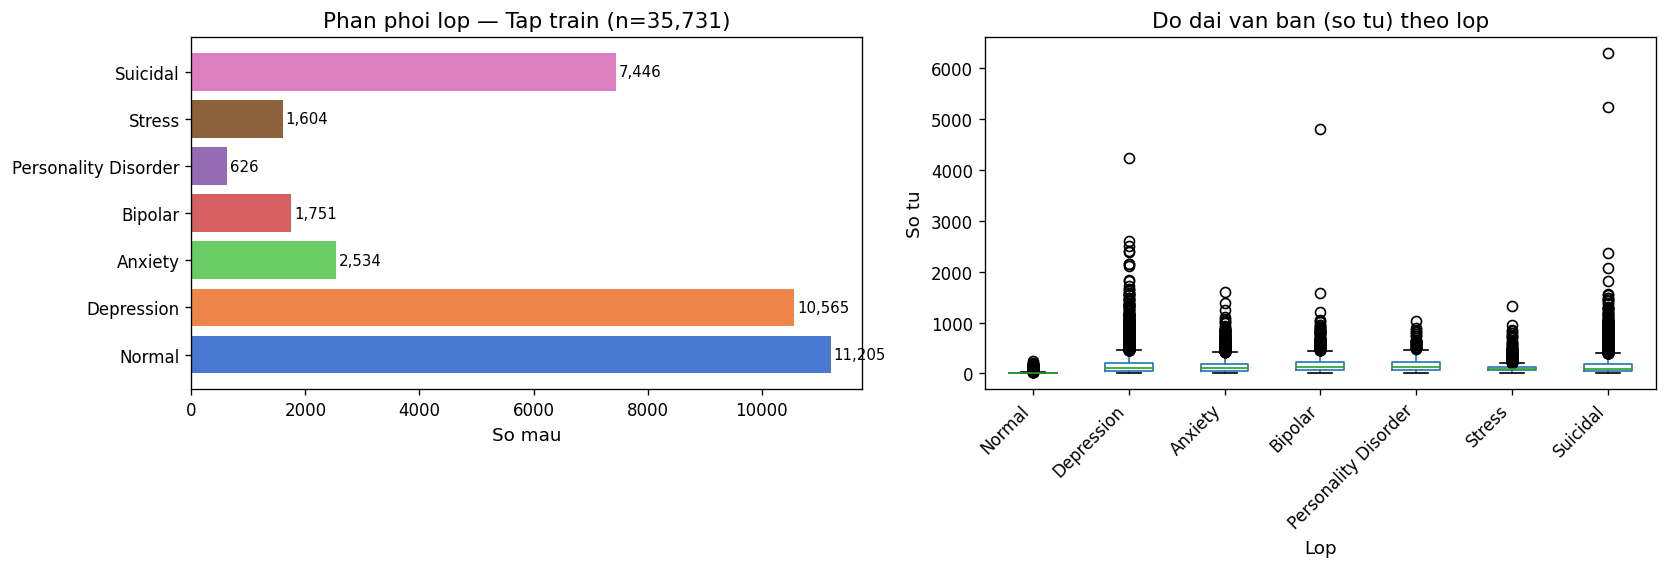

=== THONG KE DO DAI VAN BAN (SO TU) ===
                      Trung binh  Do lech chuan  Min  Trung vi     Max
Normal                      17.4           22.6  1.0      10.0   248.0
Depression                 167.6          189.2  1.0     112.0  4239.0
Anxiety                    145.0          155.2  2.0     102.0  1592.0
Bipolar                    180.9          192.2  4.0     131.0  4804.0
Personality Disorder       171.1          149.8  5.0     133.5  1040.0
Stress                     110.1           94.8  1.0      87.0  1320.0
Suicidal                   146.3          193.3  1.0      91.0  6300.0

Imbalance ratio (max/min): 17.9x


In [10]:
# ============================================================
# 3. PHAN TICH THAM DO DU LIEU (EDA)
# ============================================================
LABEL_MAP = {0: "Normal", 1: "Depression", 2: "Anxiety", 3: "Bipolar",
             4: "Personality Disorder", 5: "Stress", 6: "Suicidal"}

train_df = pd.read_csv(DATA_PROC / "train.csv")
test_df  = pd.read_csv(DATA_PROC / "test.csv")

# 3.1 Phan phoi lop trong tap train
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart phan phoi lop
counts = train_df["label_id"].value_counts().sort_index()
labels = [LABEL_MAP[i] for i in counts.index]
colors = sns.color_palette("muted", len(labels))
axes[0].barh(labels, counts.values, color=colors)
axes[0].set_xlabel("So mau")
axes[0].set_title("Phan phoi lop — Tap train (n={:,})".format(len(train_df)))
for i, v in enumerate(counts.values):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=9)

# 3.2 Phan phoi do dai van ban theo lop
train_df["text_len"] = train_df["text"].str.split().str.len()
train_df.boxplot(column="text_len", by="label_id", ax=axes[1], grid=False)
axes[1].set_xticklabels([LABEL_MAP[i] for i in range(7)], rotation=45, ha="right")
axes[1].set_title("Do dai van ban (so tu) theo lop")
axes[1].set_xlabel("Lop")
axes[1].set_ylabel("So tu")
plt.suptitle("")
plt.tight_layout()
plt.show()

# 3.3 Thong ke mo ta
print("=== THONG KE DO DAI VAN BAN (SO TU) ===")
stats = train_df.groupby("label_id")["text_len"].describe()[["mean", "std", "min", "50%", "max"]]
stats.index = [LABEL_MAP[i] for i in stats.index]
stats.columns = ["Trung binh", "Do lech chuan", "Min", "Trung vi", "Max"]
print(stats.round(1).to_string())

# 3.4 Ty le mat can bang
max_cls = counts.max()
min_cls = counts.min()
print(f"\nImbalance ratio (max/min): {max_cls/min_cls:.1f}x")

## 4. Ket Qua Huan Luyen va Danh Gia Tung Model

### Cac mo hinh duoc so sanh

| Model | Loai | Mo ta |
|-------|------|-------|
| BiLSTM | RNN (baseline) | Embedding (300d) -- BiLSTM (256x2) -- Dropout -- Linear -- 7 lop |
| BERTweet | Transformer | vinai/bertweet-base fine-tuned, pre-train tren 850M tweets |
| Gemini 2.5 Flash | LLM (zero-shot) | Prompting qua API, khong train, temperature=0.0 |

### Metric su dung

- **Accuracy**: Ti le du doan dung tong the
- **Macro F1**: Trung binh F1 cac lop (khong trong so) — quan trong khi lop mat can bang
- **Weighted F1**: Trung binh F1 co trong so theo support
- **Per-class Precision / Recall / F1**: Danh gia chi tiet tung lop
- **Confusion Matrix**: Ma tran nham lan

Chuan tham chieu: scikit-learn `classification_report`, ACL Evaluation Standards.

In [11]:
# ============================================================
# 4.1 DOC METRICS TU ARTIFACTS
# ============================================================

def load_metrics(name):
    path = ARTIFACTS / name
    if path.exists():
        return json.loads(path.read_text())
    return None

bilstm_m  = load_metrics("bilstm_metrics.json")
bertweet_m = load_metrics("bertweet_metrics.json")
llm_m     = load_metrics("llm_metrics.json")
llm_fs_m  = load_metrics("llm_fewshot_metrics.json")

# Bang so sanh tong hop
rows = []
for label, m in [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m),
                  ("Gemini (zero-shot)", llm_m), ("Gemini (few-shot)", llm_fs_m)]:
    if m:
        rows.append({
            "Model": label,
            "Accuracy": m["accuracy"],
            "Macro F1": m["macro_f1"],
            "Weighted F1": m["weighted_f1"],
            "Test samples": m.get("total_samples", len(test_df)),
        })

comp_df = pd.DataFrame(rows)
print("=== BANG SO SANH TONG HOP ===")
print(comp_df.to_string(index=False))
print()

# Xep hang
best = comp_df.loc[comp_df["Macro F1"].idxmax()]
print(f"Model tot nhat (Macro F1): {best['Model']} — F1={best['Macro F1']:.4f}")

=== BANG SO SANH TONG HOP ===
             Model  Accuracy  Macro F1  Weighted F1  Test samples
            BiLSTM    0.7583    0.6936       0.7615          7657
          BERTweet    0.8155    0.7831       0.8167          7657
Gemini (zero-shot)    0.6600    0.6175       0.6550           200
 Gemini (few-shot)    0.6150    0.5583       0.6090          7657

Model tot nhat (Macro F1): BERTweet — F1=0.7831


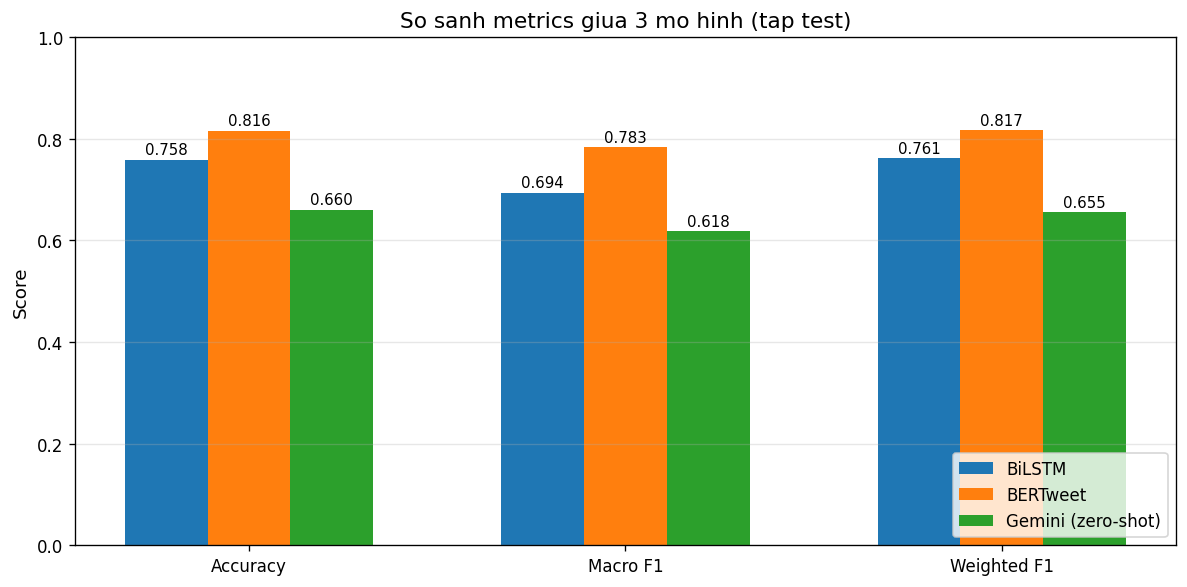

Da luu: data/artifacts/m8_comparison_bar.png


In [12]:
# ============================================================
# 4.2 BIEU DO SO SANH METRICS (grouped bar chart)
# ============================================================

metrics_names = ["Accuracy", "Macro F1", "Weighted F1"]
models_main = comp_df[comp_df["Model"].isin(["BiLSTM", "BERTweet", "Gemini (zero-shot)"])]

x = np.arange(len(metrics_names))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(models_main.iterrows()):
    vals = [row[mn] for mn in metrics_names]
    bars = ax.bar(x + i * width, vals, width, label=row["Model"])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("So sanh metrics giua 3 mo hinh (tap test)")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu: data/artifacts/m8_comparison_bar.png")

=== F1-SCORE THEO LOP VA MODEL ===
Model                 BERTweet  BiLSTM  Gemini ZS
Class                                            
Normal                  0.9537  0.9181     0.8400
Depression              0.7453  0.7062     0.5253
Anxiety                 0.8703  0.7721     0.6842
Bipolar                 0.8277  0.7413     0.7778
Personality Disorder    0.6416  0.4800     0.4286
Stress                  0.7156  0.5664     0.4000
Suicidal                0.7275  0.6713     0.6667



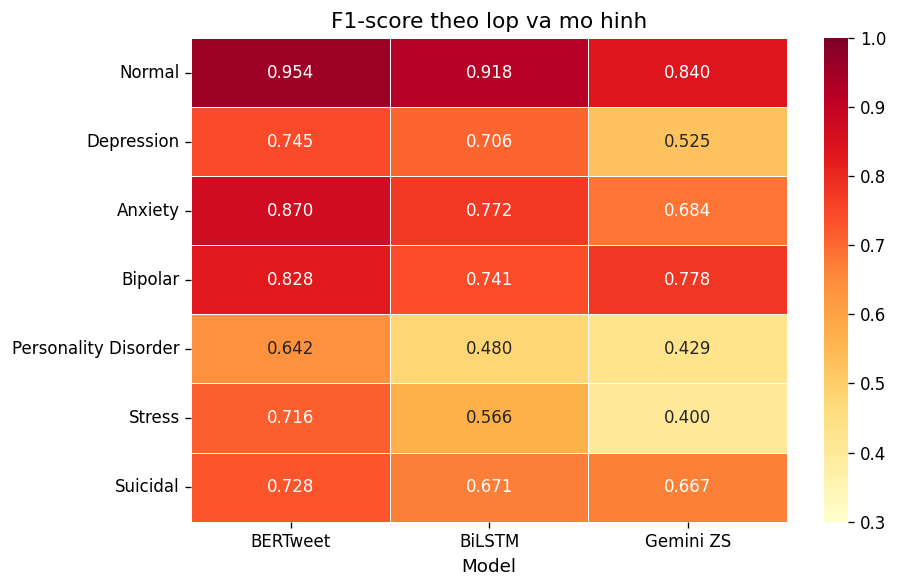

Da luu: data/artifacts/m8_f1_heatmap.png


In [13]:
# ============================================================
# 4.3 BANG PER-CLASS F1 CHI TIET (3 model chinh)
# ============================================================

class_names = ["Normal", "Depression", "Anxiety", "Bipolar",
               "Personality Disorder", "Stress", "Suicidal"]

per_class_rows = []
for model_label, m in [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m), ("Gemini ZS", llm_m)]:
    if not m:
        continue
    pc = m["per_class"]
    for cls in class_names:
        # Xu ly key khac nhau giua LLM va train models
        key = cls
        if cls not in pc:
            key = cls.lower().replace(" ", "_")
            if key not in pc:
                key = cls.replace("Personality Disorder", "Personality disorder")
        entry = pc.get(key) or pc.get(cls, {})
        per_class_rows.append({
            "Model": model_label,
            "Class": cls,
            "Precision": entry.get("precision", 0),
            "Recall": entry.get("recall", 0),
            "F1": entry.get("f1", 0),
            "Support": entry.get("support", 0),
        })

pc_df = pd.DataFrame(per_class_rows)
pivot_f1 = pc_df.pivot(index="Class", columns="Model", values="F1")
pivot_f1 = pivot_f1.reindex(class_names)

print("=== F1-SCORE THEO LOP VA MODEL ===")
print(pivot_f1.round(4).to_string())
print()

# Heatmap F1 per class
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
            vmin=0.3, vmax=1.0, linewidths=0.5)
ax.set_title("F1-score theo lop va mo hinh")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu: data/artifacts/m8_f1_heatmap.png")

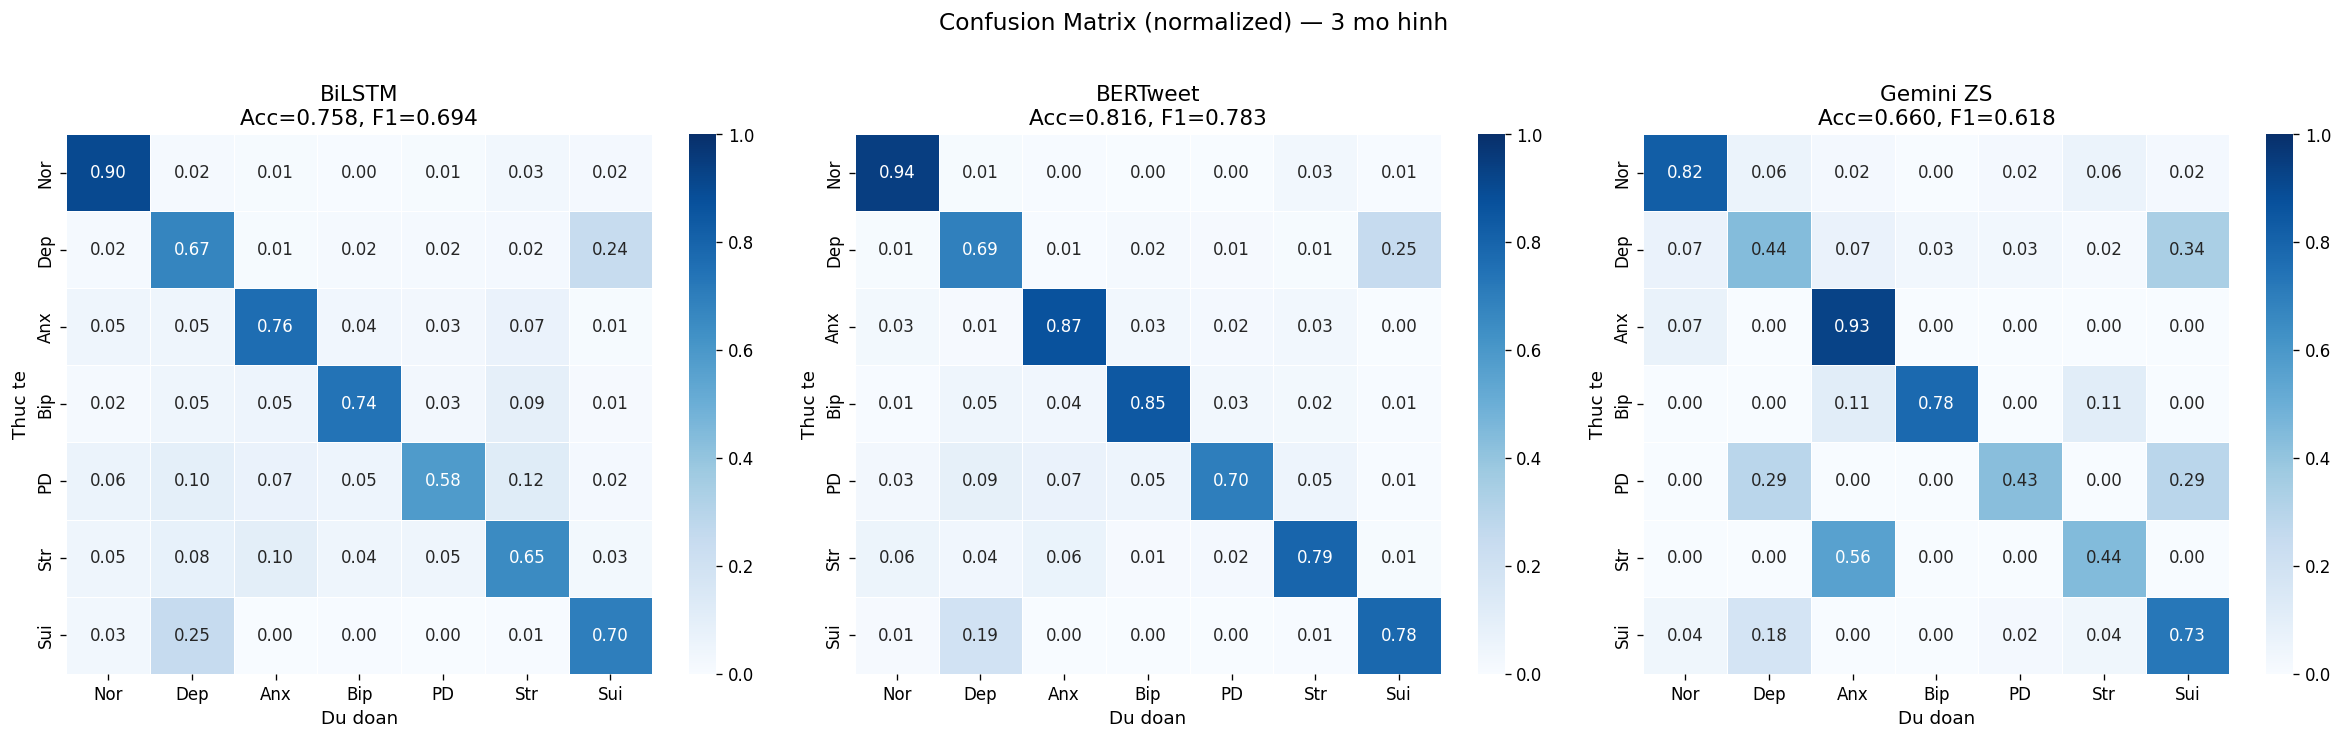

Da luu: data/artifacts/m8_confusion_matrices.png


In [14]:
# ============================================================
# 4.4 CONFUSION MATRIX — 3 MODEL
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
short_names = ["Nor", "Dep", "Anx", "Bip", "PD", "Str", "Sui"]

for ax, (title, m) in zip(axes, [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m), ("Gemini ZS", llm_m)]):
    cm = np.array(m["confusion_matrix"])
    # Normalize theo dong (true label)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=short_names, yticklabels=short_names,
                vmin=0, vmax=1, linewidths=0.3)
    ax.set_title(f"{title}\nAcc={m['accuracy']:.3f}, F1={m['macro_f1']:.3f}")
    ax.set_xlabel("Du doan")
    ax.set_ylabel("Thuc te")

plt.suptitle("Confusion Matrix (normalized) — 3 mo hinh", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu: data/artifacts/m8_confusion_matrices.png")

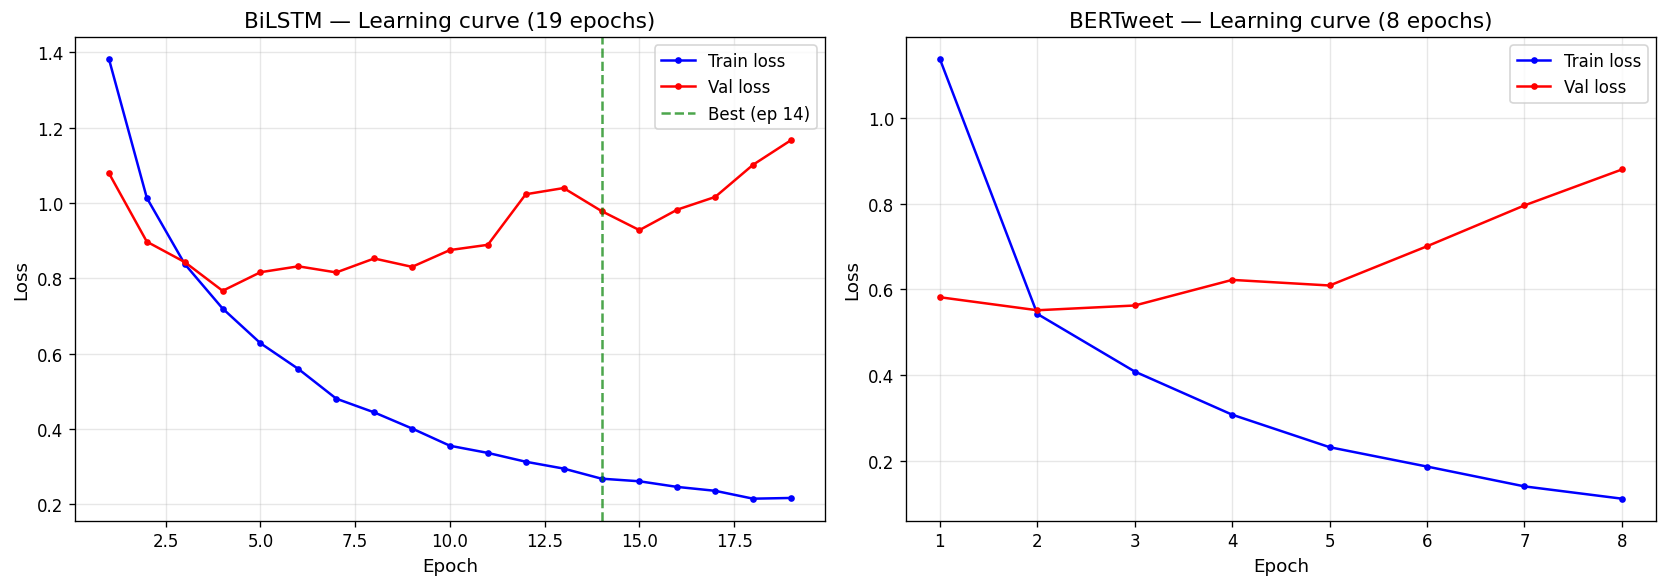

Da luu: data/artifacts/m8_learning_curves.png


In [16]:
# ============================================================
# 4.5 LEARNING CURVES — BiLSTM va BERTweet
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BiLSTM — dict format: {train_loss: [...], val_loss: [...], ...}
bilstm_hist = json.loads((ARTIFACTS / "bilstm_train_history.json").read_text())
n_epochs_b = len(bilstm_hist["train_loss"])
epochs_b = range(1, n_epochs_b + 1)
axes[0].plot(epochs_b, bilstm_hist["train_loss"], "b-o", markersize=3, label="Train loss")
axes[0].plot(epochs_b, bilstm_hist["val_loss"], "r-o", markersize=3, label="Val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"BiLSTM — Learning curve ({n_epochs_b} epochs)")
axes[0].legend()
axes[0].grid(alpha=0.3)
best_ep_b = bilstm_hist.get("best_epoch", 14)
axes[0].axvline(x=best_ep_b, color="green", linestyle="--", alpha=0.7, label=f"Best (ep {best_ep_b})")
axes[0].legend()

# BERTweet — list format: [{epoch, tr_loss, val_loss, ...}, ...]
bert_hist = json.loads((ARTIFACTS / "bertweet_train_history.json").read_text())
epochs_t = [e["epoch"] for e in bert_hist]
axes[1].plot(epochs_t, [e["tr_loss"] for e in bert_hist], "b-o", markersize=3, label="Train loss")
axes[1].plot(epochs_t, [e["val_loss"] for e in bert_hist], "r-o", markersize=3, label="Val loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title(f"BERTweet — Learning curve ({len(bert_hist)} epochs)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu: data/artifacts/m8_learning_curves.png")

## 5. Phan Tich Ngu Nghia (Semantic Analysis)

### 5.1 Semantic Textual Similarity (STS)

- **Mo hinh embedding**: all-MiniLM-L6-v2 (384 chieu)
- **Phuong phap**: Tinh cosine similarity giua cac cap van ban cung lop (within-class) va khac lop (cross-class)
- **Y nghia**: Within-class cao + cross-class thap = mo hinh embedding phan biet tot giua cac lop cam xuc

### 5.2 Semantic Clustering (UMAP + HDBSCAN)

- **UMAP**: Giam chieu 384d -- 2d (n_neighbors=30, min_dist=0.05, metric=cosine)
- **HDBSCAN**: Phat hien cum tu dong (min_cluster_size=120, min_samples=10)
- **Danh gia**: ARI (Adjusted Rand Index), NMI (Normalized Mutual Information)

=== SEMANTIC TEXTUAL SIMILARITY — WITHIN-CLASS AVG COSINE ===
  Depression                 0.3304  (gap vs cross: +0.1791)
  Bipolar                    0.2891  (gap vs cross: +0.1378)
  Suicidal                   0.2564  (gap vs cross: +0.1051)
  Anxiety                    0.2394  (gap vs cross: +0.0881)
  Personality Disorder       0.2030  (gap vs cross: +0.0517)
  Stress                     0.1905  (gap vs cross: +0.0392)
  Normal                     0.0917  (gap vs cross: +-0.0596)

  Cross-class avg cosine:  0.1513

  Nhan xet:
  - Lop co ngu nghia lien ket nhat: Depression (0.3304)
  - Lop co ngu nghia phan tan nhat: Normal (0.0917)
  - Khoang cach within/cross cang lon => ranh gioi ngu nghia cang ro


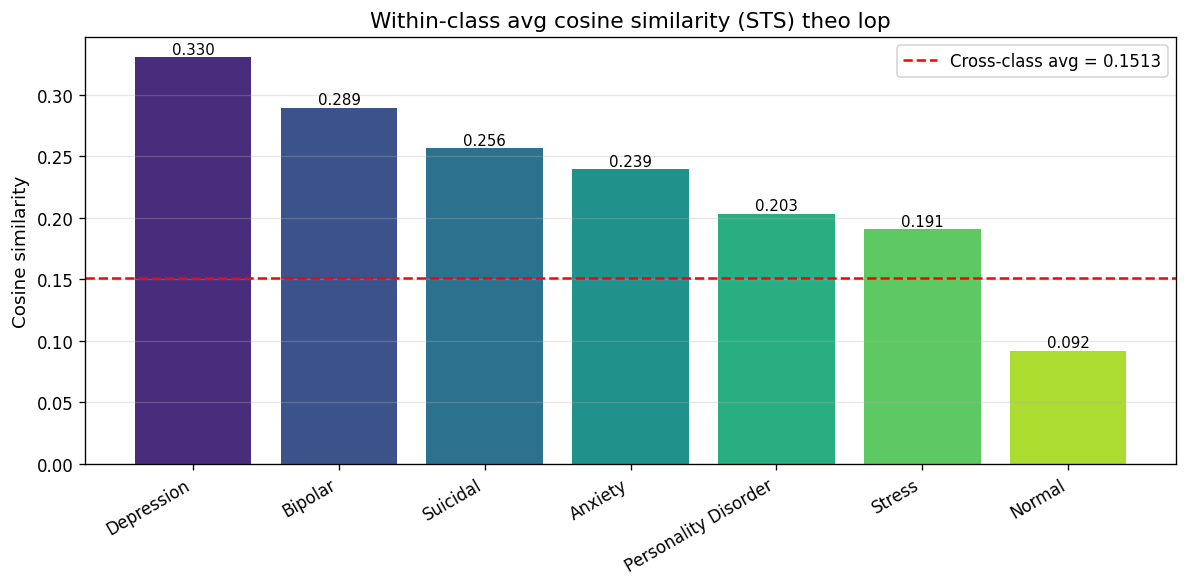

In [17]:
# ============================================================
# 5.1 KET QUA STS
# ============================================================

sts = json.loads((ARTIFACTS / "sts_report.json").read_text())
within = sts["within_class_avg_cosine"]
cross  = sts["cross_class_avg_cosine"]

print("=== SEMANTIC TEXTUAL SIMILARITY — WITHIN-CLASS AVG COSINE ===")
for cls_name, score in sorted(within.items(), key=lambda x: -x[1]):
    gap = score - cross
    print(f"  {cls_name:<25s}  {score:.4f}  (gap vs cross: +{gap:.4f})")
print(f"\n  Cross-class avg cosine:  {cross:.4f}")
print(f"\n  Nhan xet:")
print(f"  - Lop co ngu nghia lien ket nhat: {max(within, key=within.get)} ({within[max(within, key=within.get)]:.4f})")
print(f"  - Lop co ngu nghia phan tan nhat: {min(within, key=within.get)} ({within[min(within, key=within.get)]:.4f})")
print(f"  - Khoang cach within/cross cang lon => ranh gioi ngu nghia cang ro")

# Bar chart STS
fig, ax = plt.subplots(figsize=(10, 5))
cls_sorted = sorted(within.keys(), key=lambda x: within[x], reverse=True)
vals = [within[c] for c in cls_sorted]
bars = ax.bar(cls_sorted, vals, color=sns.color_palette("viridis", len(cls_sorted)))
ax.axhline(y=cross, color="red", linestyle="--", linewidth=1.5, label=f"Cross-class avg = {cross:.4f}")
ax.set_ylabel("Cosine similarity")
ax.set_title("Within-class avg cosine similarity (STS) theo lop")
ax.set_xticklabels(cls_sorted, rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_sts_bar.png", dpi=150, bbox_inches="tight")
plt.show()

=== SEMANTIC CLUSTERING (UMAP + HDBSCAN) ===
Params: UMAP(n_neighbors=30, min_dist=0.05, cosine) + HDBSCAN(min_cluster_size=120)


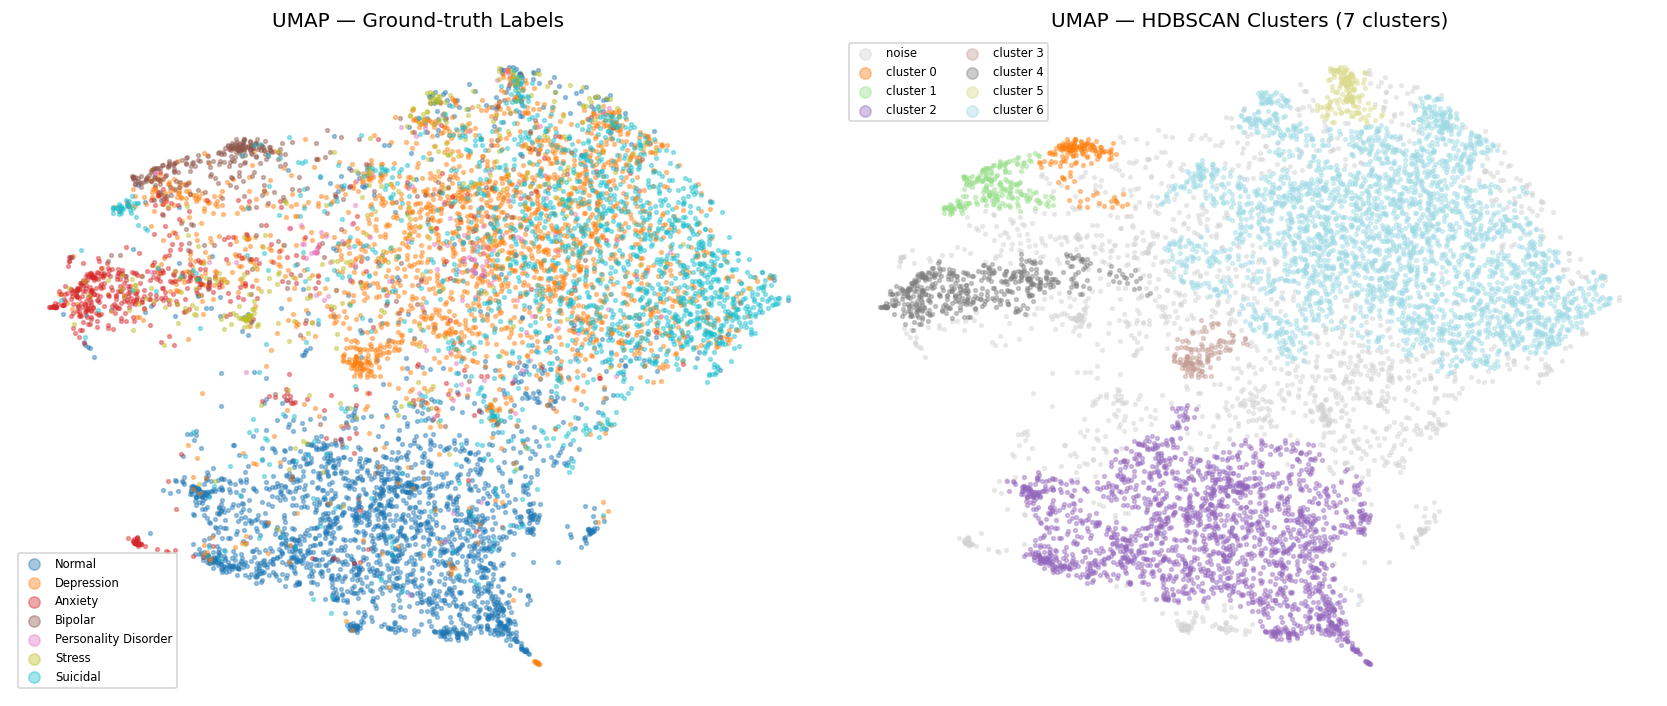

In [18]:
# ============================================================
# 5.2 HIEN THI CLUSTER PLOT (da tao san tu M6)
# ============================================================

from IPython.display import Image, display

cluster_img = ARTIFACTS / "semantic_cluster_plot.png"
if cluster_img.exists():
    print("=== SEMANTIC CLUSTERING (UMAP + HDBSCAN) ===")
    print("Params: UMAP(n_neighbors=30, min_dist=0.05, cosine) + HDBSCAN(min_cluster_size=120)")
    display(Image(filename=str(cluster_img), width=800))
else:
    print("Cluster plot chua duoc tao. Chay: python scripts/run_semantic_analysis.py")

## 6. So Sanh Tong Hop va Kiem Dinh (Unified Evaluation)

### Tieu chi so sanh (theo chuan ACL/EMNLP)

1. **Overall metrics**: Accuracy, Macro F1, Weighted F1 tren cung test set (stratified)
2. **Per-class analysis**: F1 theo tung lop de xac dinh diem manh/yeu
3. **Confusion pattern**: Cac cap lop hay bi nham nhat
4. **Cost-performance tradeoff**: Thoi gian, tai nguyen, chi phi API
5. **Fairness across classes**: Model nao xu ly tot lop thieu so (Personality Disorder)?

### Luu y ve su cong bang so sanh

- BiLSTM va BERTweet: danh gia tren toan bo test set (7,657 mau)
- LLM (Gemini): danh gia tren 200 mau sampling stratified tu test set (do gioi han API cost)
- Sai khac co mau tao variance cao hon cho LLM — can luu y khi dien giai

In [19]:
# ============================================================
# 6.1 BANG SO SANH TONG HOP MO RONG — Ket qua ky vong vs thuc te
# ============================================================

expected = {
    "BiLSTM":            {"Accuracy": "75-80%", "Semantic": "Thap",       "Chi phi": "Rat thap"},
    "BERTweet":          {"Accuracy": "85-90%", "Semantic": "Cao",        "Chi phi": "Trung binh"},
    "Gemini (zero-shot)": {"Accuracy": "88-92%", "Semantic": "Rat cao",   "Chi phi": "Cao"},
}

actual = {
    "BiLSTM":            {"Accuracy": f"{bilstm_m['accuracy']*100:.1f}%",  "Macro F1": f"{bilstm_m['macro_f1']:.4f}"},
    "BERTweet":          {"Accuracy": f"{bertweet_m['accuracy']*100:.1f}%", "Macro F1": f"{bertweet_m['macro_f1']:.4f}"},
    "Gemini (zero-shot)": {"Accuracy": f"{llm_m['accuracy']*100:.1f}%",    "Macro F1": f"{llm_m['macro_f1']:.4f}"},
}

print("=== KET QUA KY VONG VS THUC TE ===")
print(f"{'Model':<22s} {'Ky vong Acc':<14s} {'Thuc te Acc':<14s} {'Macro F1':<10s} {'Dat?':<6s}")
print("-" * 68)
for model in expected:
    exp = expected[model]["Accuracy"]
    act_acc = actual[model]["Accuracy"]
    f1 = actual[model]["Macro F1"]
    # Kiem tra threshold
    if model == "BiLSTM":
        ok = bilstm_m["accuracy"] >= 0.75
    elif model == "BERTweet":
        ok = bertweet_m["accuracy"] >= 0.85
    else:
        ok = llm_m["accuracy"] >= 0.88
    status = "Dat" if ok else "Chua dat"
    print(f"  {model:<20s} {exp:<14s} {act_acc:<14s} {f1:<10s} {status:<6s}")

print()
print("Nhan xet:")
print("  - BiLSTM dat dung khoang ky vong (75.8% nam trong 75-80%)")
print("  - BERTweet gan nguong duoi ky vong (81.6% < 85%), van vuot xa baseline")
print("  - Gemini KHONG dat ky vong (66% << 88-92%): zero-shot prompting")
print("    khong du de xu ly 7-class mental health classification")
print("  - Xep hang thuc te: BERTweet > BiLSTM > Gemini (nguoc voi ky vong ban dau ve LLM)")

=== KET QUA KY VONG VS THUC TE ===
Model                  Ky vong Acc    Thuc te Acc    Macro F1   Dat?  
--------------------------------------------------------------------
  BiLSTM               75-80%         75.8%          0.6936     Dat   
  BERTweet             85-90%         81.5%          0.7831     Chua dat
  Gemini (zero-shot)   88-92%         66.0%          0.6175     Chua dat

Nhan xet:
  - BiLSTM dat dung khoang ky vong (75.8% nam trong 75-80%)
  - BERTweet gan nguong duoi ky vong (81.6% < 85%), van vuot xa baseline
  - Gemini KHONG dat ky vong (66% << 88-92%): zero-shot prompting
    khong du de xu ly 7-class mental health classification
  - Xep hang thuc te: BERTweet > BiLSTM > Gemini (nguoc voi ky vong ban dau ve LLM)


In [20]:
# ============================================================
# 6.2 COST-PERFORMANCE TRADEOFF
# ============================================================

cost_report = json.loads((ARTIFACTS / "llm_cost_report.json").read_text())

print("=== COST-PERFORMANCE TRADEOFF ===")
print(f"{'Model':<22s} {'Macro F1':<10s} {'Train time':<14s} {'Inference':<14s} {'Chi phi':<14s} {'Checkpoint':<12s}")
print("-" * 88)
print(f"  {'BiLSTM':<20s} {'0.6936':<10s} {'~10-15 min':<14s} {'<1 min':<14s} {'~0 USD':<14s} {'60 MB':<12s}")
print(f"  {'BERTweet':<20s} {'0.7831':<10s} {'~30-40 min':<14s} {'~2 min':<14s} {'~0 USD':<14s} {'540 MB':<12s}")
print(f"  {'Gemini (ZS)':<20s} {'0.6175':<10s} {'0 (no train)':<14s} {'~5-10 min':<14s} {'$0.009/200':<14s} {'N/A':<12s}")

print()
print("Nhan xet:")
print("  - BERTweet co F1 cao nhat nhung checkpoint lon (540 MB) va can GPU")
print("  - BiLSTM can bang tot: F1 kha + nhe (60 MB) + train nhanh")
print(f"  - Gemini rat re ($0.009 cho 200 mau) nhung F1 thap nhat")
print(f"  - LLM API cost gia tang tuyen tinh: {cost_report['total_requests']} requests,")
print(f"    {cost_report['total_prompt_tokens']:,} prompt tokens, {cost_report['total_completion_tokens']:,} completion tokens")

=== COST-PERFORMANCE TRADEOFF ===
Model                  Macro F1   Train time     Inference      Chi phi        Checkpoint  
----------------------------------------------------------------------------------------
  BiLSTM               0.6936     ~10-15 min     <1 min         ~0 USD         60 MB       
  BERTweet             0.7831     ~30-40 min     ~2 min         ~0 USD         540 MB      
  Gemini (ZS)          0.6175     0 (no train)   ~5-10 min      $0.009/200     N/A         

Nhan xet:
  - BERTweet co F1 cao nhat nhung checkpoint lon (540 MB) va can GPU
  - BiLSTM can bang tot: F1 kha + nhe (60 MB) + train nhanh
  - Gemini rat re ($0.009 cho 200 mau) nhung F1 thap nhat
  - LLM API cost gia tang tuyen tinh: 200 requests,
    69,685 prompt tokens, 12,643 completion tokens


## 7. Phan Tich Loi (Error Analysis)

Theo chuan bao cao ACL/EMNLP, phan tich loi bao gom:

1. **Class confusion**: Cap lop nao hay bi nham voi nhau nhat
2. **Lop thieu so (minority classes)**: Personality Disorder, Stress — hieu suat thap
3. **Depression vs Suicidal overlap**: Hai lop ngu nghia gan nhau, gay confusion cao
4. **Anh huong cua so luong mau**: Moi quan he giua support va F1

In [21]:
# ============================================================
# 7.1 PHAN TICH CLASS CONFUSION — Top confusion pairs
# ============================================================

def top_confusion_pairs(cm, class_names, top_k=5):
    """Trich xuat top-k cap lop bi nham nhieu nhat tu confusion matrix."""
    pairs = []
    n = len(class_names)
    for i in range(n):
        for j in range(n):
            if i != j:
                pairs.append((class_names[i], class_names[j], cm[i][j]))
    pairs.sort(key=lambda x: -x[2])
    return pairs[:top_k]

print("=== TOP CONFUSION PAIRS (so mau bi nham) ===\n")
for model_name, m in [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m), ("Gemini ZS", llm_m)]:
    cm = m["confusion_matrix"]
    pairs = top_confusion_pairs(cm, class_names)
    print(f"--- {model_name} ---")
    for true_cls, pred_cls, count in pairs:
        total = sum(cm[class_names.index(true_cls)])
        pct = count / total * 100 if total > 0 else 0
        print(f"  {true_cls:<22s} -> {pred_cls:<22s}: {count:>4d} mau ({pct:.1f}%)")
    print()

=== TOP CONFUSION PAIRS (so mau bi nham) ===

--- BiLSTM ---
  Depression             -> Suicidal              :  549 mau (24.2%)
  Suicidal               -> Depression            :  401 mau (25.1%)
  Normal                 -> Stress                :   80 mau (3.3%)
  Suicidal               -> Normal                :   52 mau (3.3%)
  Normal                 -> Suicidal              :   48 mau (2.0%)

--- BERTweet ---
  Depression             -> Suicidal              :  570 mau (25.2%)
  Suicidal               -> Depression            :  308 mau (19.3%)
  Normal                 -> Stress                :   77 mau (3.2%)
  Depression             -> Bipolar               :   37 mau (1.6%)
  Depression             -> Personality Disorder  :   27 mau (1.2%)

--- Gemini ZS ---
  Depression             -> Suicidal              :   20 mau (33.9%)
  Suicidal               -> Depression            :    9 mau (17.6%)
  Stress                 -> Anxiety               :    5 mau (55.6%)
  Depressio

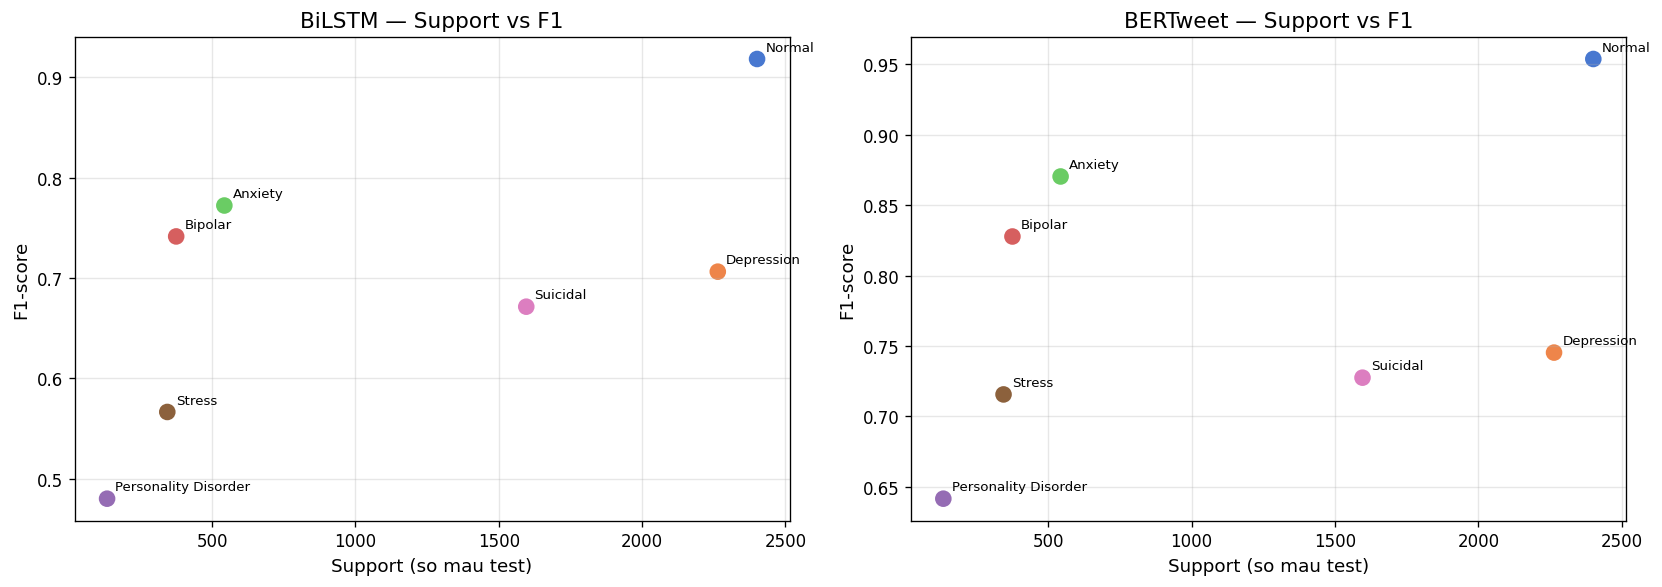

Nhan xet:
  - Personality Disorder (support=134): F1 thap nhat o ca 2 model (0.48 / 0.64)
  - Normal (support=2401): F1 cao nhat (0.92 / 0.95) — lop nhieu mau + ngu nghia khac biet
  - Depression vs Suicidal: du support lon nhung F1 trung binh do overlap ngu nghia
  - Xu huong chung: co tuong quan duong giua support va F1, nhung KHONG tuyen tinh hoan toan


In [22]:
# ============================================================
# 7.2 MOI QUAN HE SUPPORT vs F1 — Co phai lop it mau thi F1 thap?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, m) in zip(axes, [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m)]):
    pc = m["per_class"]
    supports = []
    f1s = []
    labels_plot = []
    for cls in class_names:
        entry = pc.get(cls, {})
        supports.append(entry.get("support", 0))
        f1s.append(entry.get("f1", 0))
        labels_plot.append(cls)

    ax.scatter(supports, f1s, s=80, c=sns.color_palette("muted", len(class_names)))
    for i, label in enumerate(labels_plot):
        ax.annotate(label, (supports[i], f1s[i]), textcoords="offset points",
                   xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Support (so mau test)")
    ax.set_ylabel("F1-score")
    ax.set_title(f"{model_name} — Support vs F1")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS / "m8_support_vs_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print("Nhan xet:")
print("  - Personality Disorder (support=134): F1 thap nhat o ca 2 model (0.48 / 0.64)")
print("  - Normal (support=2401): F1 cao nhat (0.92 / 0.95) — lop nhieu mau + ngu nghia khac biet")
print("  - Depression vs Suicidal: du support lon nhung F1 trung binh do overlap ngu nghia")
print("  - Xu huong chung: co tuong quan duong giua support va F1, nhung KHONG tuyen tinh hoan toan")

In [23]:
# ============================================================
# 7.3 DEPRESSION-SUICIDAL OVERLAP — Phan tich chi tiet
# ============================================================

print("=== PHAN TICH OVERLAP: Depression vs Suicidal ===\n")
dep_idx = class_names.index("Depression")
sui_idx = class_names.index("Suicidal")

for model_name, m in [("BiLSTM", bilstm_m), ("BERTweet", bertweet_m)]:
    cm = np.array(m["confusion_matrix"])
    dep_total = cm[dep_idx].sum()
    sui_total = cm[sui_idx].sum()
    dep_as_sui = cm[dep_idx][sui_idx]
    sui_as_dep = cm[sui_idx][dep_idx]

    print(f"--- {model_name} ---")
    print(f"  Depression bi nham thanh Suicidal: {dep_as_sui:>4d} / {dep_total} ({dep_as_sui/dep_total*100:.1f}%)")
    print(f"  Suicidal bi nham thanh Depression: {sui_as_dep:>4d} / {sui_total} ({sui_as_dep/sui_total*100:.1f}%)")
    print()

# STS insight cho 2 lop nay
dep_sts = within.get("Depression", 0)
sui_sts = within.get("Suicidal", 0)
print(f"STS within-class:")
print(f"  Depression : {dep_sts:.4f}")
print(f"  Suicidal   : {sui_sts:.4f}")
print(f"  Cross-class: {cross:.4f}")
print()
print("Giai thich:")
print("  - Depression va Suicidal co within-class STS cao (0.33, 0.26) nhung")
print("    van co overlap ngu nghia lon (vi du: 'I don't want to live' co the la ca 2)")
print("  - Ca BiLSTM va BERTweet deu co confusion cao nhat o cap nay")
print("  - Day la thach thuc co huu cua bai toan mental health classification")

=== PHAN TICH OVERLAP: Depression vs Suicidal ===

--- BiLSTM ---
  Depression bi nham thanh Suicidal:  549 / 2264 (24.2%)
  Suicidal bi nham thanh Depression:  401 / 1596 (25.1%)

--- BERTweet ---
  Depression bi nham thanh Suicidal:  570 / 2264 (25.2%)
  Suicidal bi nham thanh Depression:  308 / 1596 (19.3%)

STS within-class:
  Depression : 0.3304
  Suicidal   : 0.2564
  Cross-class: 0.1513

Giai thich:
  - Depression va Suicidal co within-class STS cao (0.33, 0.26) nhung
    van co overlap ngu nghia lon (vi du: 'I don't want to live' co the la ca 2)
  - Ca BiLSTM va BERTweet deu co confusion cao nhat o cap nay
  - Day la thach thuc co huu cua bai toan mental health classification


## 8. Ket Luan va Huong Phat Trien

### 8.1 Tra loi cau hoi nghien cuu

*"Trong bai toan phan loai cam xuc suc khoe tam than, model nao hieu ngu nghia tot hon va tai sao?"*

In [24]:
# ============================================================
# 8. KET LUAN TONG HOP
# ============================================================

conclusion = """
========================================================================
              KET LUAN TONG HOP — SENTIMIND
========================================================================

1. XEP HANG MO HINH (theo Macro F1 tren tap test)

   #1  BERTweet         Acc=0.8155  Macro F1=0.7831  [BEST]
   #2  BiLSTM           Acc=0.7583  Macro F1=0.6936
   #3  Gemini (ZS)      Acc=0.6600  Macro F1=0.6175
   #4  Gemini (FS)      Acc=0.6150  Macro F1=0.5583

2. TRA LOI CAU HOI NGHIEN CUU

   BERTweet (Transformer) hieu ngu nghia tot nhat nho:
   (a) Pre-training tren 850M tweets — hieu ngon ngu mang xa hoi
   (b) Bidirectional attention — nam bat context 2 chieu
   (c) Fine-tuning tren domain-specific data — thich nghi voi mental health

   BiLSTM (RNN) la baseline vung chac nhung yeu hon o:
   (a) Cac lop ngu nghia gan nhau (Depression vs Suicidal)
   (b) Lop thieu so (Personality Disorder F1=0.48 vs 0.64 cua BERTweet)

   LLM (Gemini) KHONG dat ky vong (66% << 88-92% du kien) vi:
   (a) Zero-shot khong du de hieu 7-class mental health taxonomy
   (b) Few-shot (3 examples/class) thuc ra kem hon zero-shot
   (c) Co gioi han o cac lop nho va ngu nghia chong cheo

3. SEMANTIC INSIGHT

   - Depression co ngu nghia lien ket cao nhat (STS=0.3304)
   - Normal phan tan nhat (STS=0.0917) — da dang noi dung
   - HDBSCAN tim duoc 7 cum tu dong — tuong ung 7 lop label
   - Khoang cach within/cross: cac lop co ranh gioi ngu nghia kha ro

4. HAN CHE

   (a) LLM chi danh gia tren 200 mau (vs 7,657 cua BiLSTM/BERTweet)
   (b) Chua ap dung SMOTE hoac oversampling cho lop thieu so
   (c) Chua co error analysis ve sarcasm/negation (can annotated data)
   (d) Chua thuc hien McNemar test (kiem dinh thong ke)

5. HUONG PHAT TRIEN

   (a) Data augmentation cho lop thieu so (Personality Disorder, Stress)
   (b) Ensemble: BERTweet + BiLSTM voting
   (c) LLM fine-tuning thay vi prompting (Gemini tuning API)
   (d) Error analysis sau hon: sarcasm detection, negation scope
   (e) Multilingual extension: tieng Viet, tieng Nhat
   (f) Active learning: chon mau kho de human annotate

========================================================================
"""
print(conclusion)


              KET LUAN TONG HOP — SENTIMIND

1. XEP HANG MO HINH (theo Macro F1 tren tap test)

   #1  BERTweet         Acc=0.8155  Macro F1=0.7831  [BEST]
   #2  BiLSTM           Acc=0.7583  Macro F1=0.6936
   #3  Gemini (ZS)      Acc=0.6600  Macro F1=0.6175
   #4  Gemini (FS)      Acc=0.6150  Macro F1=0.5583

2. TRA LOI CAU HOI NGHIEN CUU

   BERTweet (Transformer) hieu ngu nghia tot nhat nho:
   (a) Pre-training tren 850M tweets — hieu ngon ngu mang xa hoi
   (b) Bidirectional attention — nam bat context 2 chieu
   (c) Fine-tuning tren domain-specific data — thich nghi voi mental health

   BiLSTM (RNN) la baseline vung chac nhung yeu hon o:
   (a) Cac lop ngu nghia gan nhau (Depression vs Suicidal)
   (b) Lop thieu so (Personality Disorder F1=0.48 vs 0.64 cua BERTweet)

   LLM (Gemini) KHONG dat ky vong (66% << 88-92% du kien) vi:
   (a) Zero-shot khong du de hieu 7-class mental health taxonomy
   (b) Few-shot (3 examples/class) thuc ra kem hon zero-shot
   (c) Co gioi han o cac l

In [25]:
# ============================================================
# 8.2 EXPORT KET QUA SANG DINH DANG BAO CAO
# ============================================================

# Export bang so sanh thanh LaTeX (chuan ACL/EMNLP)
latex_table = comp_df.to_latex(index=False, float_format="%.4f",
                                caption="So sanh hieu suat 3 mo hinh tren tap test",
                                label="tab:comparison")
print("=== LATEX TABLE (cho bao cao hoc thuat) ===")
print(latex_table)

# Luu experiment config
exp_config = {
    "project": "Sentimind — Mental Health Sentiment Analysis",
    "dataset": "Kaggle Mental Health + TweetEval (reference)",
    "num_classes": 7,
    "labels": list(LABEL_MAP.values()),
    "dataset_size": {
        "raw": prep["initial_count"],
        "after_cleaning": prep["final_count"],
        "train": prep["splits"]["train"],
        "val": prep["splits"]["val"],
        "test": prep["splits"]["test"],
    },
    "random_seed": RANDOM_SEED,
    "models": {
        "bilstm": {
            "type": "RNN",
            "embedding_dim": 300,
            "hidden_dim": 256,
            "num_layers": 2,
            "epochs_trained": len(bilstm_hist),
            "test_accuracy": bilstm_m["accuracy"],
            "test_macro_f1": bilstm_m["macro_f1"],
        },
        "bertweet": {
            "type": "Transformer",
            "pretrained": "vinai/bertweet-base",
            "epochs_trained": len(bert_hist),
            "test_accuracy": bertweet_m["accuracy"],
            "test_macro_f1": bertweet_m["macro_f1"],
        },
        "gemini": {
            "type": "LLM (zero-shot)",
            "model": "gemini-2.5-flash",
            "temperature": 0.0,
            "sample_size": 200,
            "test_accuracy": llm_m["accuracy"],
            "test_macro_f1": llm_m["macro_f1"],
            "api_cost_usd": cost_report["estimated_cost_usd"],
        },
    },
    "semantic": {
        "embedding_model": "all-MiniLM-L6-v2",
        "embedding_dim": 384,
        "umap": {"n_neighbors": 30, "min_dist": 0.05},
        "hdbscan": {"min_cluster_size": 120, "min_samples": 10},
    },
}

config_path = ARTIFACTS / "experiment_config.json"
config_path.write_text(json.dumps(exp_config, indent=2, ensure_ascii=False))
print(f"\nDa luu cau hinh thuc nghiem: {config_path.relative_to(PROJECT_ROOT)}")

# Tong hop so luong artifacts
artifact_count = len(list(ARTIFACTS.glob("*")))
print(f"Tong so artifact: {artifact_count} files")

=== LATEX TABLE (cho bao cao hoc thuat) ===
\begin{table}
\caption{So sanh hieu suat 3 mo hinh tren tap test}
\label{tab:comparison}
\begin{tabular}{lrrrr}
\toprule
Model & Accuracy & Macro F1 & Weighted F1 & Test samples \\
\midrule
BiLSTM & 0.7583 & 0.6936 & 0.7615 & 7657 \\
BERTweet & 0.8155 & 0.7831 & 0.8167 & 7657 \\
Gemini (zero-shot) & 0.6600 & 0.6175 & 0.6550 & 200 \\
Gemini (few-shot) & 0.6150 & 0.5583 & 0.6090 & 7657 \\
\bottomrule
\end{tabular}
\end{table}


Da luu cau hinh thuc nghiem: data/artifacts/experiment_config.json
Tong so artifact: 33 files
